Perfect — this is the **final upgrade from “physics correct glass” → “realistic glass”** using:

👉 **Schlick approximation (Fresnel reflectance)**

This is what makes glass look:

* reflective at grazing angles
* transparent when facing camera
* realistic (used in real renderers)

---

# 1. Core Idea (Why Schlick exists)

Real glass does NOT behave like:

> “always refract or always reflect”

Instead:

* Head-on → mostly refract
* Side angle → mostly reflect

So probability changes with angle.

---

# 2. Key physics quantities

## Snell + geometry

$$
\cos\theta = -\mathbf{R} \cdot \mathbf{N}
$$

$$
\sin\theta = \sqrt{1 - \cos^2\theta}
$$

---

## Total Internal Reflection condition

$$
ri \cdot \sin\theta > 1
$$

---

# 3. Schlick approximation (core formula)

## Reflectance:

$$
R(\theta) = R_0 + (1 - R_0)(1 - \cos\theta)^5
$$

where:

$$
R_0 = \left(\frac{1 - \eta}{1 + \eta}\right)^2
$$

---

# 4. Meaning table

| Term         | Formula                      | Purpose                               |
| ------------ | ---------------------------- | ------------------------------------- |
| $R_0$        | $(\frac{1-\eta}{1+\eta})^2$  | base reflectivity at normal incidence |
| $\cos\theta$ | $-\mathbf{R}\cdot\mathbf{N}$ | view angle                            |
| Schlick term | $(1-\cos\theta)^5$           | sharp angle boost                     |
| final R      | mix                          | probability of reflection             |

---

# 5. Decision logic (IMPORTANT)

| Condition                 | Action                               |
| ------------------------- | ------------------------------------ |
| Total internal reflection | reflect only                         |
| otherwise                 | reflect OR refract probabilistically |

---

# 6. FULL PYTHON IMPLEMENTATION (CORRECT)

```python id="q9k2lx"
import math
import random

from util.ray import Ray
from util.vec3 import Vec3, unit_vector, dot, reflect


class Dielectric:
    def __init__(self, refraction_index):
        # η (eta): refractive index of material (glass ~1.5)
        self.refraction_index = refraction_index

    # ==========================================
    # SCHLICK APPROXIMATION (Fresnel reflectance)
    # ==========================================
    def reflectance(self, cosine, ref_idx):

        # STEP 1: compute base reflectivity R0
        # CHANGE: replaces full Fresnel equations
        r0 = (1 - ref_idx) / (1 + ref_idx)
        r0 = r0 * r0

        # STEP 2: angle-based adjustment
        # (1 - cosθ)^5 makes grazing angles highly reflective
        return r0 + (1 - r0) * pow((1 - cosine), 5)

    def scatter(self, r_in, rec):

        # ==========================================
        # STEP 1: no absorption in glass
        # ==========================================
        attenuation = Vec3(1.0, 1.0, 1.0)

        # ==========================================
        # STEP 2: compute refraction ratio
        # CHANGE: handles inside/outside medium
        # ==========================================
        if rec.front_face:
            ri = 1.0 / self.refraction_index
        else:
            ri = self.refraction_index

        # ==========================================
        # STEP 3: normalize ray direction
        # ==========================================
        unit_dir = unit_vector(r_in.direction())

        # ==========================================
        # STEP 4: compute cos(theta)
        # ==========================================
        cos_theta = min(dot(-unit_dir, rec.normal), 1.0)

        # ==========================================
        # STEP 5: compute sin(theta)
        # ==========================================
        sin_theta = math.sqrt(1.0 - cos_theta * cos_theta)

        # ==========================================
        # STEP 6: check Total Internal Reflection
        # CHANGE: added realism condition
        # ==========================================
        cannot_refract = ri * sin_theta > 1.0

        # ==========================================
        # STEP 7: Schlick probability
        # CHANGE: NEW compared to previous version
        # ==========================================
        reflect_prob = self.reflectance(cos_theta, ri)

        # ==========================================
        # STEP 8: probabilistic decision
        # ==========================================
        if cannot_refract or random.random() < reflect_prob:
            # REFLECTION (mirror behavior)
            direction = reflect(unit_dir, rec.normal)

        else:
            # REFRACTION (Snell's law)
            direction = refract(unit_dir, rec.normal, ri)

        # ==========================================
        # STEP 9: final ray
        # ==========================================
        scattered = Ray(rec.p, direction)

        return scattered, attenuation
```

---

# 7. What changed from your previous dielectric

## ❌ Old model

* deterministic (always refract or reflect)
* no angle-based realism
* glass looked “fake but stable”

---

## ✔ New Schlick model

| Feature            | Old    | New           |
| ------------------ | ------ | ------------- |
| reflection         | fixed  | probabilistic |
| grazing angles     | weak   | mirror-like   |
| realism            | medium | high          |
| film-quality glass | ❌      | ✔             |

---

# 8. Key intuition (very important)

Think:

> Glass is not a switch — it's a probability system

---

# 9. Visual result you should see

### At different angles:

| Angle      | Behavior                    |
| ---------- | --------------------------- |
| front view | transparent                 |
| side view  | mirror-like                 |
| edges      | bright reflection           |
| corners    | mixed reflection/refraction |

---

# 10. Final mental model

Dielectric =

> Snell’s law + Total Internal Reflection + Schlick probability

---

If you want next upgrade, I can show:

### 👉 Why Schlick formula works (derivation intuition)

### 👉 or “real glass rendering pipeline used in games”

### 👉 or fix your full ray tracer architecture (no more bugs like earlier)

Just say 👍


In [1]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [2]:
from util.material import Material
from util.ray import Ray
from util.vec3 import Vec3, reflect, unit_vector, random_unit_vector, dot
class Metal(Material):
    def __init__(self, albedo, fuzz=0.0):
        # metal color
        self.albedo = albedo

        # surface roughness (0 = perfect mirror, 1 = very rough)
        self.fuzz = min(fuzz, 1.0)

    def scatter(self, r_in, rec):

        # ==========================================
        # STEP 1: normalize incoming ray direction
        # ==========================================
        unit_dir = unit_vector(r_in.direction())

        # ==========================================
        # STEP 2: perfect reflection direction
        # R = V - 2(V·N)N
        # ==========================================
        reflected = reflect(unit_dir, rec.normal)

        # ==========================================
        # STEP 3: add fuzz (surface imperfection)
        # ==========================================
        scattered_dir = reflected + self.fuzz * random_unit_vector()

        # ==========================================
        # STEP 4: build scattered ray
        # ==========================================
        scattered = Ray(rec.p, scattered_dir)

        # ==========================================
        # STEP 5: energy attenuation (metal tint)
        # ==========================================
        attenuation = self.albedo

        # ==========================================
        # MUST return exactly 2 values
        # ==========================================
        return scattered, attenuation

In [3]:
import math
from util.ray import Ray
from util.vec3 import Vec3, unit_vector, dot


def refract(uv, n, etai_over_etat):
    """
    Vector refraction based on Snell's Law.

    uv : unit incident direction
    n  : surface normal
    etai_over_etat : ratio of refractive indices (η / η')
    """

    # ==========================================
    # STEP 1: cos(theta)
    # cosθ = min(-uv · n, 1)
    # ==========================================
    cos_theta = min(dot(-uv, n), 1.0)

    # ==========================================
    # STEP 2: perpendicular component
    # R⊥ = (η/η') (uv + cosθ n)
    # ==========================================
    r_out_perp = (uv + n * cos_theta) * etai_over_etat

    # ==========================================
    # STEP 3: parallel component
    # R∥ = -sqrt(1 - |R⊥|²) n
    # ==========================================
    r_out_parallel = n * (-math.sqrt(abs(1.0 - r_out_perp.length_squared())))

    # ==========================================
    # STEP 4: final refracted direction
    # ==========================================
    return r_out_perp + r_out_parallel

In [4]:
import math
import random

from util.ray import Ray
from util.vec3 import Vec3, unit_vector, dot, reflect


class Dielectric:
    def __init__(self, refraction_index):
        # η (eta): refractive index of material (glass ~1.5)
        self.refraction_index = refraction_index

    # ==========================================
    # SCHLICK APPROXIMATION (Fresnel reflectance)
    # ==========================================
    def reflectance(self, cosine, ref_idx):

        # STEP 1: compute base reflectivity R0
        # CHANGE: replaces full Fresnel equations
        r0 = (1 - ref_idx) / (1 + ref_idx)
        r0 = r0 * r0

        # STEP 2: angle-based adjustment
        # (1 - cosθ)^5 makes grazing angles highly reflective
        return r0 + (1 - r0) * pow((1 - cosine), 5)

    def scatter(self, r_in, rec):

        # ==========================================
        # STEP 1: no absorption in glass
        # ==========================================
        attenuation = Vec3(1.0, 1.0, 1.0)

        # ==========================================
        # STEP 2: compute refraction ratio
        # CHANGE: handles inside/outside medium
        # ==========================================
        if rec.front_face:
            ri = 1.0 / self.refraction_index
        else:
            ri = self.refraction_index

        # ==========================================
        # STEP 3: normalize ray direction
        # ==========================================
        unit_dir = unit_vector(r_in.direction())

        # ==========================================
        # STEP 4: compute cos(theta)
        # ==========================================
        cos_theta = min(dot(-unit_dir, rec.normal), 1.0)

        # ==========================================
        # STEP 5: compute sin(theta)
        # ==========================================
        sin_theta = math.sqrt(1.0 - cos_theta * cos_theta)

        # ==========================================
        # STEP 6: check Total Internal Reflection
        # CHANGE: added realism condition
        # ==========================================
        cannot_refract = ri * sin_theta > 1.0

        # ==========================================
        # STEP 7: Schlick probability
        # CHANGE: NEW compared to previous version
        # ==========================================
        reflect_prob = self.reflectance(cos_theta, ri)

        # ==========================================
        # STEP 8: probabilistic decision
        # ==========================================
        if cannot_refract or random.random() < reflect_prob:
            # REFLECTION (mirror behavior)
            direction = reflect(unit_dir, rec.normal)

        else:
            # REFRACTION (Snell's law)
            direction = refract(unit_dir, rec.normal, ri)

        # ==========================================
        # STEP 9: final ray
        # ==========================================
        scattered = Ray(rec.p, direction)

        return scattered, attenuation

In [5]:
from util.vec3 import Vec3, Color, Point3

from util.metal.lambertian import Lambertian
#from util.metal.metal import Metal
#from util.metal.dielectric import Dielectric
from util.metal.sphere import Sphere
from util.metal.hittable_list import HittableList
from util.metal.camera import Camera


# ==========================================
# WORLD
# ==========================================
world = HittableList()


# ==========================================
# MATERIALS (C++ → Python mapping)
# ==========================================

# Diffuse
material_ground = Lambertian(Color(0.8, 0.8, 0.0))
material_center = Lambertian(Color(0.1, 0.2, 0.5))

# Metal (right sphere)
material_right = Metal(Color(0.8, 0.6, 0.2), 1.0)

# Dielectric (air bubble in water scene)
# C++: 1.00 / 1.33
material_left = Dielectric(1.0 / 1.33)


# ==========================================
# SCENE OBJECTS
# ==========================================

# Ground
world.add(
    Sphere(
        Point3(0.0, -100.5, -1.0),
        100.0,
        material_ground
    )
)

# Center sphere (diffuse)
world.add(
    Sphere(
        Point3(0.0, 0.0, -1.2),
        0.5,
        material_center
    )
)

# Left sphere (GLASS / AIR BUBBLE)
world.add(
    Sphere(
        Point3(-1.0, 0.0, -1.0),
        0.5,
        material_left
    )
)

# Right sphere (METAL)
world.add(
    Sphere(
        Point3(1.0, 0.0, -1.0),
        0.5,
        material_right
    )
)


# ==========================================
# CAMERA
# ==========================================
cam = Camera()

cam.aspect_ratio = 16.0 / 9.0
cam.image_width = 400

cam.samples_per_pixel = 1   # FIXED (important for correct glass look)
cam.max_depth = 50


# ==========================================
# RENDER
# ==========================================
cam.render(world)

100%|██████████| 225/225 [00:08<00:00, 26.98it/s, CPU=54.5%, RAM=80.8%, CPU Temp=N/A, GPU Temp=56.0°C, VRAM=731.0MB]


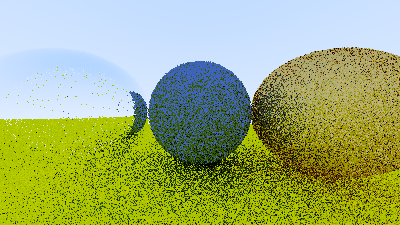

In [6]:
cam.show()